# Meridian MMM walkthrough

This notebook is the fastest way to understand the repo without reverse-engineering the scripts or pretending a portfolio piece needs to feel like homework.

It covers:
- the synthetic dataset shape
- the fast deterministic MMM pipeline that generates the portfolio figures
- the lightweight official Meridian runtime check
- where the optional slower posterior run fits in

**Default behavior:** this notebook runs the fast portfolio path and a prior-only Meridian check. That is intentional. The goal is to show a clean business story first, then prove the official package works, without making the default walkthrough sluggish for no reason.

In [1]:
from pathlib import Path
import json
import os
import sys

candidates = [Path.cwd(), Path.cwd().parent]
project_root = next((path.resolve() for path in candidates if (path / 'src').exists() and (path / 'data').exists()), None)
if project_root is None:
    raise RuntimeError('Run this notebook from the repo root or the notebooks/ directory.')

os.chdir(project_root)
sys.path.insert(0, str(project_root / 'src'))

project_root


PosixPath('/root/.openclaw/workspace/meridian-mmm-portfolio')

## 1) Inspect the bundled Meridian-style dataset

The repo ships with a synthetic weekly dataset so the project is runnable out of the box. It is not meant to fake production realism; it is meant to make the assumptions visible and the demo reproducible.

In [2]:
import pandas as pd
from IPython.display import display

df = pd.read_csv(project_root / 'data' / 'synthetic_meridian_mmm.csv', parse_dates=['week_start'])
metadata = json.loads((project_root / 'data' / 'synthetic_metadata.json').read_text())

print(f"Rows: {len(df)}")
print(f"Date range: {df['week_start'].min().date()} → {df['week_start'].max().date()}")
print('Channels:', ', '.join(metadata['channels']))
display(df.head())


Rows: 110
Date range: 2022-01-03 → 2024-02-05
Channels: search, social, video, tv, affiliate


,week_start,spend_search,spend_social,spend_video,spend_tv,spend_affiliate,seasonality_index,economic_index,price_index,promo_events,organic_sessions,conversions,site_visits,revenue,total_spend,market,holiday_flag
0,2022-01-03,42755.480239,31405.712820,31494.630288,70107.078830,11430.979487,1.080000,101.952871,1.011740,0,222882.714249,2528,79000,530880,187193.881666,US,0
1,2022-01-10,45461.147796,40760.830713,35704.952867,60994.776028,12103.490735,1.110150,96.469828,1.016504,0,246217.157597,2469,77156,518490,195025.198138,US,0
2,2022-01-17,46010.617928,29644.443854,35639.861956,66117.645038,17139.028937,1.134903,99.884855,1.006570,0,251713.954079,2626,82062,551460,194551.597713,US,0
3,2022-01-24,51336.893578,29331.836519,34854.158985,76195.034193,15749.245145,1.153841,99.590890,1.022201,1,248155.169119,2718,84938,570780,207467.168420,US,0
4,2022-01-31,65418.800579,30360.485587,36310.244589,67063.007083,14426.392116,1.166906,100.769897,1.020563,0,255524.570949,2661,83156,558810,213578.929954,US,0


## 2) Run the fast portfolio pipeline

This is the main event for most reviewers. It fits the deterministic model, regenerates the figures, and writes `reports/metrics.json` so the business takeaway is obvious instead of buried in code.

In [3]:
import mmm_pipeline as pipeline

modeled_df, channel_df, metrics = pipeline.run_pipeline()

summary = (
    channel_df[['channel', 'avg_weekly_spend', 'incremental_conversions', 'roi']]
    .sort_values('roi', ascending=False)
    .assign(
        avg_weekly_spend=lambda frame: frame['avg_weekly_spend'].map(lambda value: f'${value:,.0f}'),
        incremental_conversions=lambda frame: frame['incremental_conversions'].map(lambda value: f'{value:,.0f}'),
        roi=lambda frame: frame['roi'].map(lambda value: f'{value:.2f}x'),
    )
)

print(f"MAPE: {metrics['mape']:.2%}")
display(summary.reset_index(drop=True))


MAPE: 2.00%


,channel,avg_weekly_spend,incremental_conversions,roi
0,affiliate,"$12,161","30,265",4.75x
1,search,"$50,497","37,355",1.41x
2,social,"$27,237","11,208",0.79x
3,video,"$31,796","-4,279",-0.26x
4,tv,"$57,611","-45,638",-1.51x


## 3) Review the generated figures

These are the portfolio visuals. If someone only spends two minutes in the repo, these charts plus the metrics table should still tell a coherent story.

reports/figures/conversions_actual_vs_predicted.png


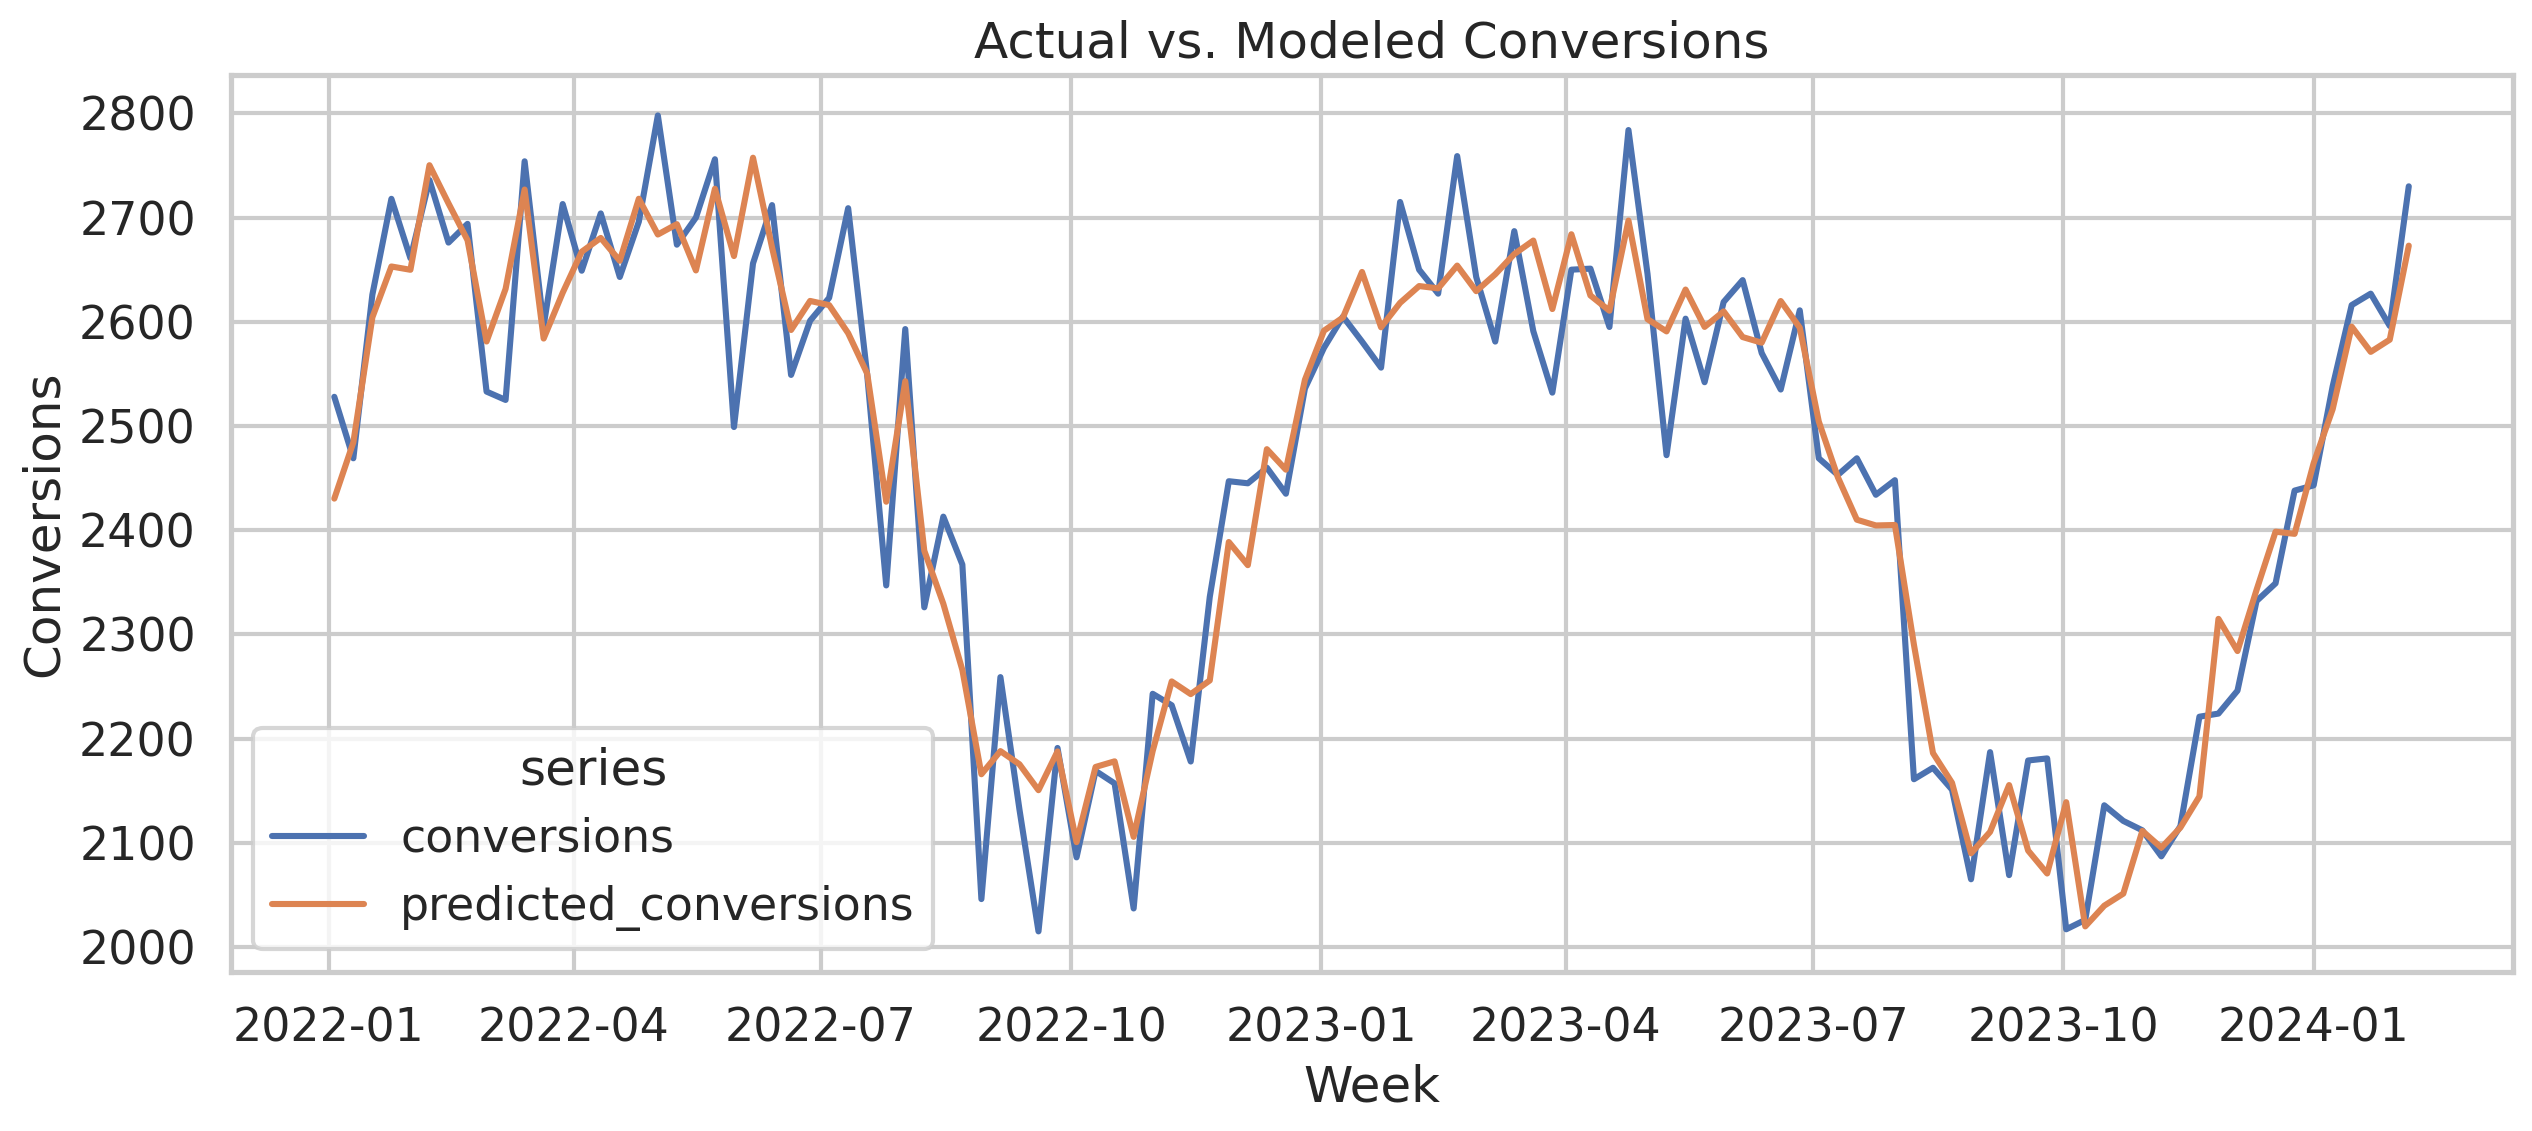

reports/figures/channel_incremental_conversions.png


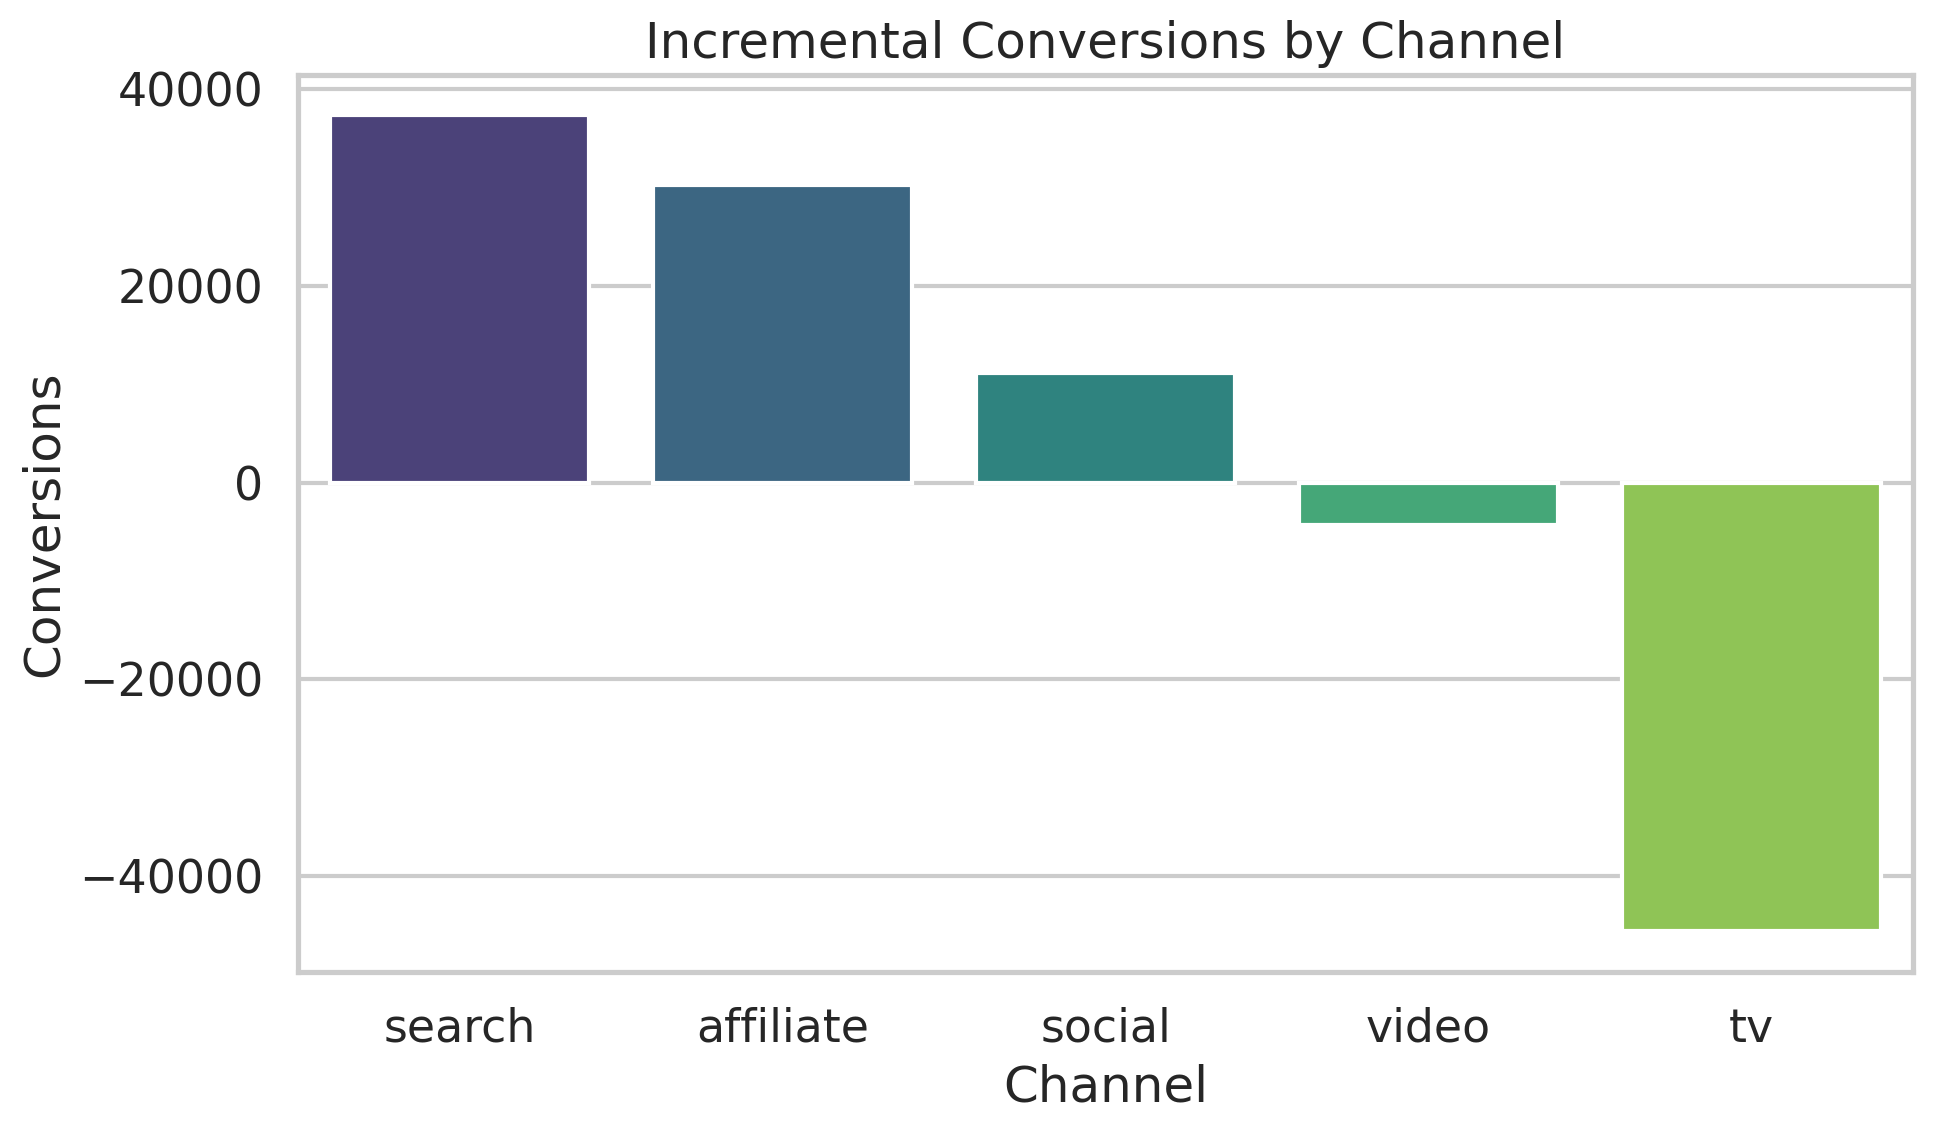

reports/figures/response_curves.png


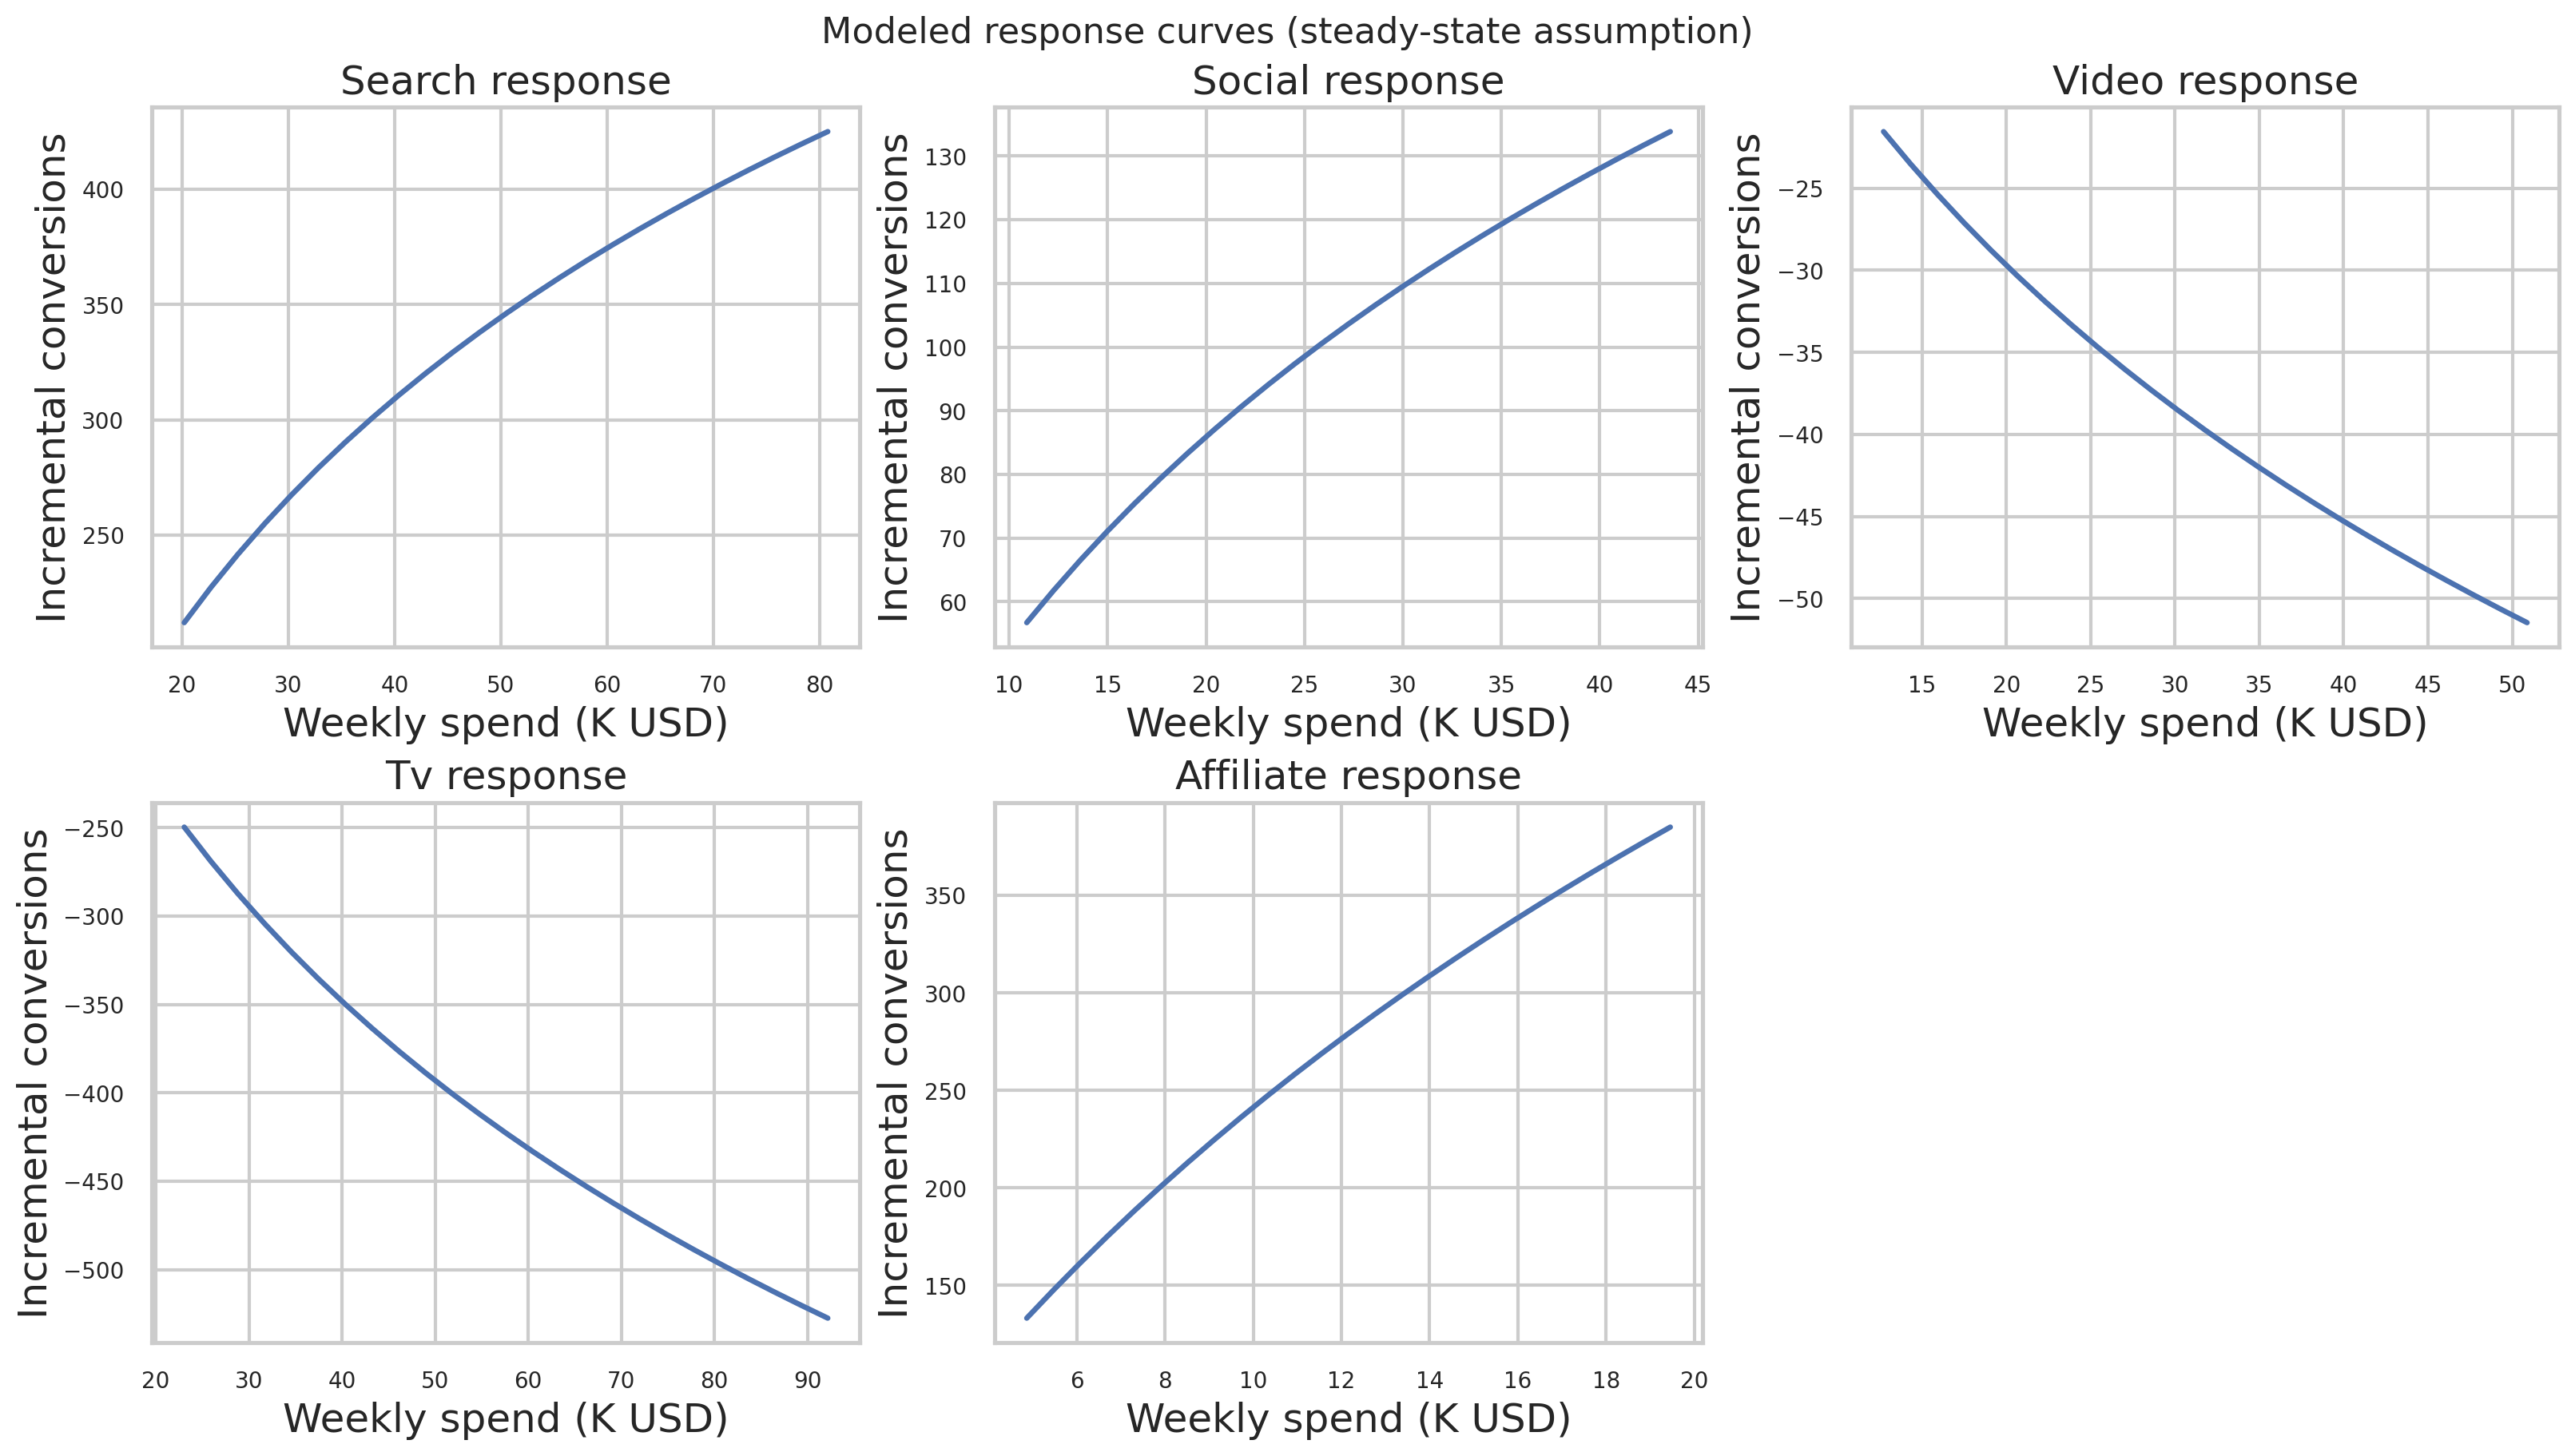

In [4]:
from IPython.display import Image

figure_paths = [
    project_root / 'reports' / 'figures' / 'conversions_actual_vs_predicted.png',
    project_root / 'reports' / 'figures' / 'channel_incremental_conversions.png',
    project_root / 'reports' / 'figures' / 'response_curves.png',
]

for figure_path in figure_paths:
    print(figure_path.relative_to(project_root))
    display(Image(filename=str(figure_path), width=900))


## 4) Run the official Meridian runtime check

Now for the proof that this is not just Meridian-flavored branding. This section exercises the official package on the same dataset and writes `reports/meridian_runtime_check.json`.

By default, the notebook stops at the model build + prior stage because that is the best speed-to-proof tradeoff for a walkthrough.

In [5]:
import subprocess

notebook_runtime_path = project_root / 'reports' / 'notebook_runtime_check.json'
prior_cmd = [sys.executable, 'src/meridian_smoke_test.py', '--output', str(notebook_runtime_path)]
print('Running:', ' '.join(prior_cmd))
completed = subprocess.run(prior_cmd, cwd=project_root, text=True, capture_output=True, check=True)
print(completed.stdout)


Running: /tmp/meridian-mmm-portfolio-venv/bin/python src/meridian_smoke_test.py --output /root/.openclaw/workspace/meridian-mmm-portfolio/reports/notebook_runtime_check.json


Meridian model built in 0.39s
Prior sample complete in 0.24s with 14 tracked variables
Wrote runtime summary to /root/.openclaw/workspace/meridian-mmm-portfolio/reports/notebook_runtime_check.json



In [6]:
runtime_summary = json.loads((project_root / 'reports' / 'notebook_runtime_check.json').read_text())
runtime_summary


{'dataset_rows': 110,
 'date_range': ['2022-01-03', '2024-02-05'],
 'media_channels': ['search', 'social', 'video', 'tv', 'affiliate'],
 'control_variables': ['seasonality_index',
  'economic_index',
  'price_index',
  'promo_events',
  'organic_sessions',
  'holiday_flag'],
 'model_build_seconds': 0.39,
 'prior_seconds': 0.24,
 'prior_draws': 5,
 'prior_variables': ['alpha_m',
  'beta_gm',
  'beta_m',
  'ec_m',
  'eta_m',
  'gamma_c',
  'gamma_gc',
  'knot_values',
  'mu_t',
  'roi_m',
  'sigma',
  'slope_m',
  'tau_g',
  'xi_c'],
 'posterior_ran': False}

## 5) Optional: run the tiny posterior

Only run this if you want extra runtime proof. It is slower on CPU and does not materially improve the portfolio story by itself. Think of it as supporting evidence, not the headline.

In [7]:
RUN_POSTERIOR = False

if RUN_POSTERIOR:
    posterior_runtime_path = project_root / 'reports' / 'notebook_runtime_check.json'
    posterior_cmd = [sys.executable, 'src/meridian_smoke_test.py', '--posterior', '--output', str(posterior_runtime_path)]
    print('Running:', ' '.join(posterior_cmd))
    completed = subprocess.run(posterior_cmd, cwd=project_root, text=True, capture_output=True, check=True)
    print(completed.stdout)
else:
    print('Posterior run skipped. Set RUN_POSTERIOR = True if you want the slower CPU smoke test.')


Posterior run skipped. Set RUN_POSTERIOR = True if you want the slower CPU smoke test.


## 6) What to tell a reviewer

If someone asks what this repo proves, the short answer is:
- the fast deterministic pipeline produces clean MMM-style business outputs
- the official Meridian package runs on the same project
- the limitations are documented instead of hidden under vague Bayesian theater

That is the whole pitch: clear analysis, believable runtime proof, and no fake production claims.